# Quantum Variational Classifier on `make_moons` Dataset

This notebook demonstrates a simple **variational quantum classifier (VQC)** using [PennyLane](https://pennylane.ai/).  
We apply a parameterized quantum circuit to classify data from the classic **two-moons dataset**, which is not linearly separable and thus provides a simple but non-trivial example.  

Steps:
1. Generate and visualize the dataset (`make_moons`).
2. Encode classical data into quantum states.
3. Define a variational quantum circuit with trainable parameters.
4. Train the circuit using gradient-based optimization.
5. Evaluate classification performance.


In [9]:
import pennylane as qml
from pennylane import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

np.random.seed(0)

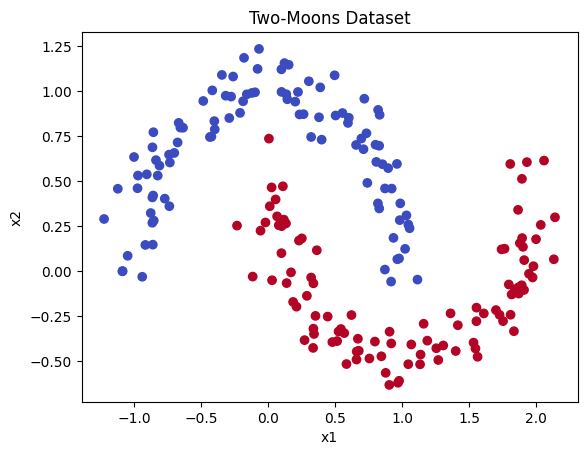

In [ ]:
# Generate a 2D "moons" dataset with two classes and split into training/testing
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Visualize dataset
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Two-Moons Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [11]:
# Define a 2-qubit quantum device for simulation
dev = qml.device("default.qubit", wires=2)

def encode_data(x):
    """Encodes 2D classical input x = (x1, x2) into qubit rotations."""
    qml.RX(x[0], wires=0)
    qml.RY(x[1], wires=1)


# Define a variational quantum circuit with trainable parameters
def variational_circuit(weights, x):
    encode_data(x)
    qml.CNOT(wires=[0, 1])
    qml.Rot(weights[0], weights[1], weights[2], wires=0)
    qml.Rot(weights[3], weights[4], weights[5], wires=1)

@qml.qnode(dev)
def circuit(weights, x):
    variational_circuit(weights, x)
    return qml.expval(qml.PauliZ(0))


# Define a function to map circuit output to binary class prediction
def predict(weights, X):
    preds = [np.sign(circuit(weights, x)) for x in X]
    # Map {-1, +1} to {0, 1}
    return (np.array(preds) > 0).astype(int)


# Cost function based on cross-entropy-like loss
def cost(weights, X, y):
    preds = [circuit(weights, x) for x in X]
    # Convert outputs to probabilities in [0,1]
    probs = (np.array(preds) + 1) / 2
    return -np.mean(y * np.log(probs + 1e-6) + (1 - y) * np.log(1 - probs + 1e-6))

In [ ]:
# Train the variational quantum classifier
weights = 0.01 * np.random.randn(6, requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.4)

epochs = 30
for epoch in range(epochs):
    weights, curr_cost = opt.step_and_cost(lambda w: cost(w, X_train, y_train), weights)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}: cost = {curr_cost:.4f}")


Epoch 5: cost = 1.1097
Epoch 10: cost = 0.7094
Epoch 15: cost = 0.6631
Epoch 20: cost = 0.6535
Epoch 25: cost = 0.6486
Epoch 30: cost = 0.6450


In [ ]:
# Evaluate classifier on test set
y_pred = predict(weights, X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {acc*100:.2f}%")


Test Accuracy: 65.00%
